In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report


In [ ]:
cancer_df=pd.read_csv(r"cancer_risk.csv") 

cancer_df.head()

,Patient_ID,Cancer_Type,Age,Age_group,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,...,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,BMI,BMI category,Physical_Activity_Level,Overall_Risk_Score,Risk_Level
0,LU0000,Breast,68,Older Adult,Female,7,2,8,No,5,...,6,3,Yes,No,0,28.0,Overweight,5,0.398696,Medium
1,LU0001,Prostate,74,Older Adult,Male,8,9,8,No,0,...,3,3,No,No,5,25.4,Overweight,9,0.424299,Medium
2,LU0002,Skin,55,Middle-Aged,Male,7,10,7,No,3,...,8,10,No,No,6,28.6,Overweight,2,0.605082,Medium
3,LU0003,Colon,61,Middle-Aged,Female,6,2,2,No,6,...,4,8,No,No,8,32.1,Obese,7,0.318449,Low
4,LU0004,Lung,67,Older Adult,Male,10,7,4,No,6,...,10,9,No,No,5,25.1,Overweight,2,0.524358,Medium


## DATA CLEANING

In [3]:
print(cancer_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Age_group                2000 non-null   object 
 4   Gender                   2000 non-null   object 
 5   Smoking                  2000 non-null   int64  
 6   Alcohol_Use              2000 non-null   int64  
 7   Obesity                  2000 non-null   int64  
 8   Family_History           2000 non-null   object 
 9   Diet_Red_Meat            2000 non-null   int64  
 10  Diet_Salted_Processed    2000 non-null   int64  
 11  Fruit_Veg_Intake         2000 non-null   int64  
 12  Physical_Activity        2000 non-null   int64  
 13  Air_Pollution            2000 non-null   int64  
 14  Occupational_Hazards    

In [4]:
cancer_df.drop(
    columns='Physical_Activity_Level',
    inplace=True
)

missing_values = cancer_df.isna().sum()

print(missing_values)

Patient_ID               0
Cancer_Type              0
Age                      0
Age_group                0
Gender                   0
Smoking                  0
Alcohol_Use              0
Obesity                  0
Family_History           0
Diet_Red_Meat            0
Diet_Salted_Processed    0
Fruit_Veg_Intake         0
Physical_Activity        0
Air_Pollution            0
Occupational_Hazards     0
BRCA_Mutation            0
H_Pylori_Infection       0
Calcium_Intake           0
BMI                      0
BMI category             0
Overall_Risk_Score       0
Risk_Level               0
dtype: int64


In [5]:
cancer_df.describe()

,Age,Smoking,Alcohol_Use,Obesity,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,Calcium_Intake,BMI,Overall_Risk_Score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,63.248000,5.157000,5.035000,5.967500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,3.94050,26.183350,0.454449
std,10.462946,3.325339,3.260996,3.061393,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,3.04887,3.947459,0.123074
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,15.000000,0.029285
25%,56.000000,2.000000,2.000000,4.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,1.00000,23.500000,0.366982
50%,64.000000,5.000000,5.000000,6.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,4.00000,26.200000,0.455399
75%,70.000000,8.000000,8.000000,9.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,6.00000,28.700000,0.539782
max,90.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,41.400000,0.852158


## EXPLORATORY ANALISIS

### Background Information

In [6]:
# Frequency and percentage of Gender
gender_freq = cancer_df['Gender'].value_counts()
gender_pct = cancer_df['Gender'].value_counts(normalize=True) * 100

gender_table = pd.DataFrame({
    'Frequency': gender_freq,
    'Percentage': gender_pct.round(2)
})

print(gender_table)

        Frequency  Percentage
Gender                       
Female       1022        51.1
Male          978        48.9


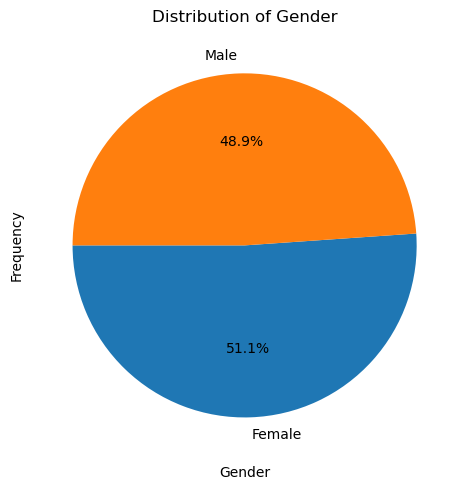

In [7]:
# Bar chart
plt.figure(figsize=(7, 5))
gender_freq.plot(kind='pie', autopct='%1.1f%%', startangle=180)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# Frequency and percentage of Cancer Type
cancer_type_freq = cancer_df['Cancer_Type'].value_counts()
cancer_type_pct = cancer_df['Cancer_Type'].value_counts(normalize=True) * 100

cancer_type_table = pd.DataFrame({
    'Frequency': cancer_type_freq,
    'Percentage': cancer_type_pct.round(2)
})
print(cancer_type_table)

             Frequency  Percentage
Cancer_Type                       
Lung               527       26.35
Breast             460       23.00
Colon              418       20.90
Prostate           305       15.25
Skin               290       14.50


C:\Users\DELL\AppData\Local\Temp\ipykernel_13460\3353419641.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancer_type_freq.index, y=cancer_type_freq.values, palette="viridis",     edgecolor='black')


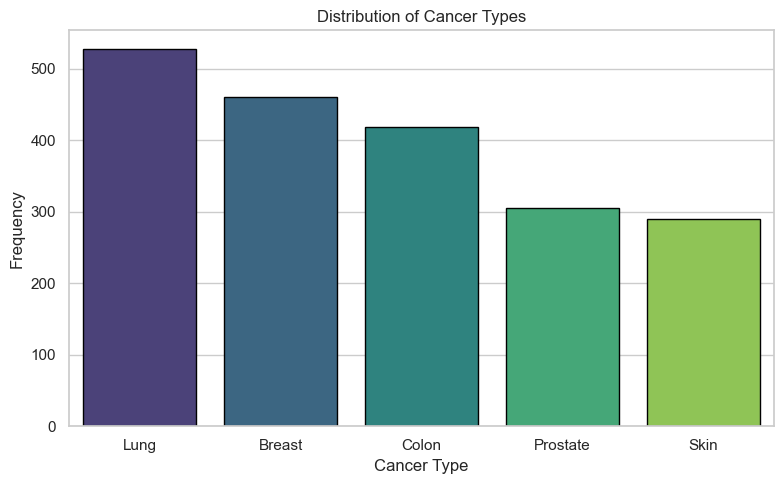

In [9]:
# Bar chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(x=cancer_type_freq.index, y=cancer_type_freq.values, palette="viridis",     edgecolor='black')

plt.title('Distribution of Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Frequency and percentage of Age Group
age_group_freq = cancer_df['Age_group'].value_counts()
age_group_pct = cancer_df['Age_group'].value_counts(normalize=True) * 100

age_group_table = pd.DataFrame({
    'Frequency': age_group_freq,
    'Percentage': age_group_pct.round(2)
})

print(age_group_table)

             Frequency  Percentage
Age_group                         
Older Adult        934       46.70
Middle-Aged        867       43.35
Adult              190        9.50
Young Adult          9        0.45


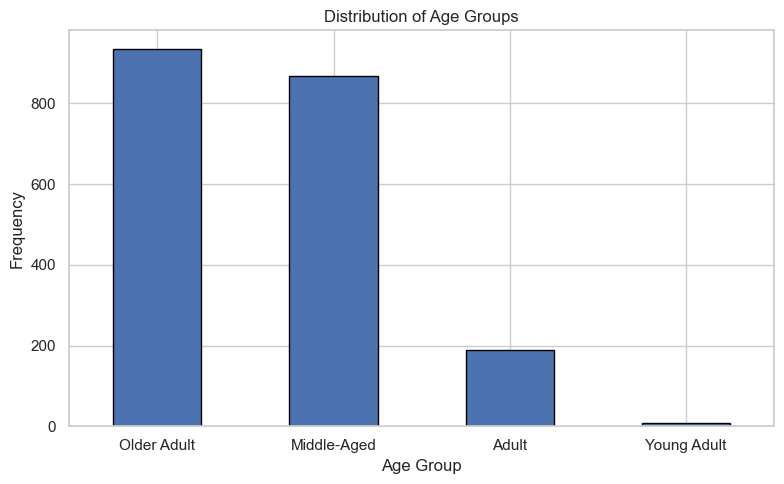

In [11]:
# Bar chart
plt.figure(figsize=(8, 5))
age_group_freq.plot(kind='bar', edgecolor='black')

plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Frequency and percentage of BMI Category
bmi_freq = cancer_df['BMI category'].value_counts()
bmi_pct = cancer_df['BMI category'].value_counts(normalize=True) * 100

bmi_table = pd.DataFrame({
    'Frequency': bmi_freq,
    'Percentage': bmi_pct.round(2)
})

print(bmi_table)

               Frequency  Percentage
BMI category                        
Overweight           918        45.9
Normal weight        700        35.0
Obese                336        16.8
Underweight           46         2.3


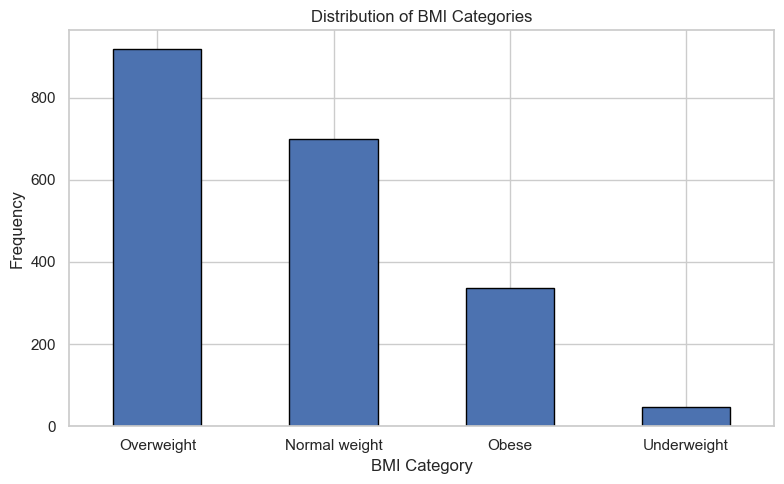

In [13]:
# Bar chart
plt.figure(figsize=(8, 5))
bmi_freq.plot(kind='bar', edgecolor='black')

plt.title('Distribution of BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Frequency and percentage of Risk Level
risk_freq = cancer_df['Risk_Level'].value_counts()
risk_pct = cancer_df['Risk_Level'].value_counts(normalize=True) * 100

risk_table = pd.DataFrame({
    'Frequency': risk_freq,
    'Percentage': risk_pct.round(2)
})

print(risk_table)

            Frequency  Percentage
Risk_Level                       
Medium           1574        78.7
Low               324        16.2
High              102         5.1


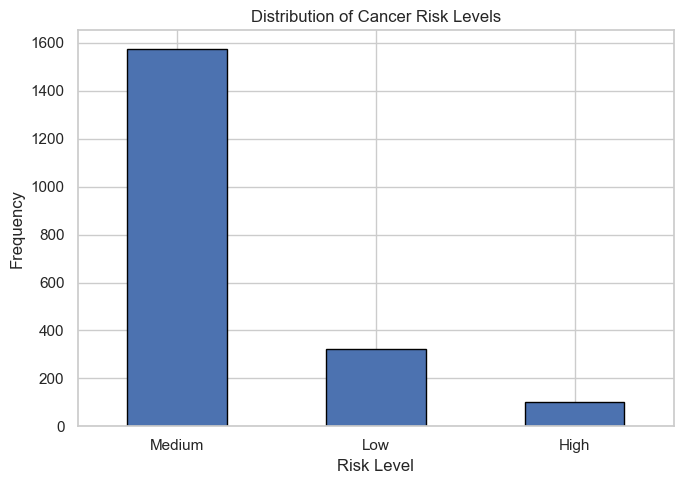

In [15]:
# Bar chart
plt.figure(figsize=(7, 5))
risk_freq.plot(kind='bar', edgecolor='black')

plt.title('Distribution of Cancer Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Lifestyle-related risk factors, including smoking, alcohol use, physical activity, and obesity-related scores, across different cancer types and risk levels. 

In [16]:
# Smoking score across Cancer Types
smoking_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Smoking'].mean().unstack()

smoking_combined = smoking_combined.reindex(columns=['Low', 'Medium', 'High'])

print(smoking_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       2.36    4.02  6.00
Colon        1.97    4.15  6.03
Lung         8.32    8.83  9.40
Prostate     2.25    4.56  4.33
Skin         2.12    4.01  5.90


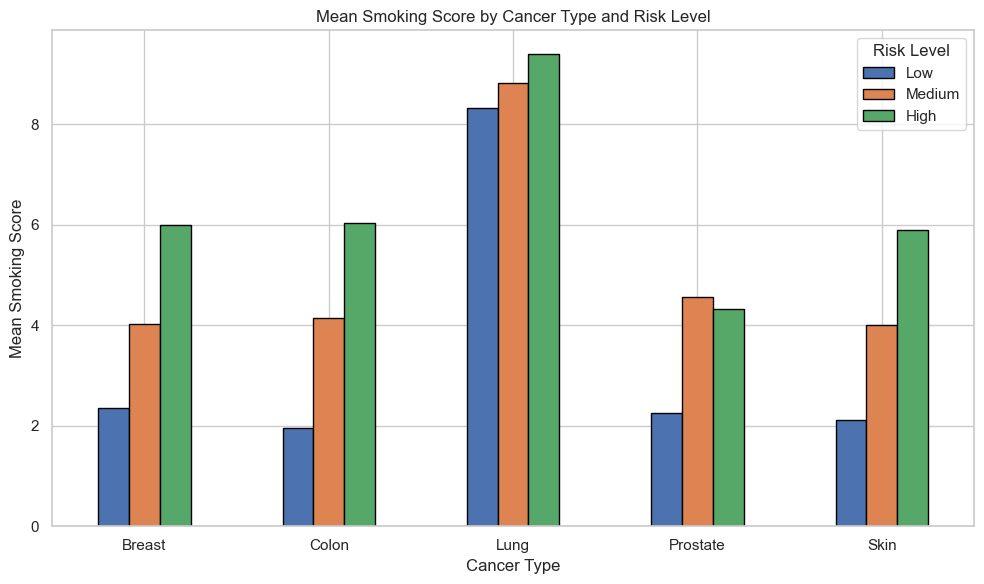

In [17]:
smoking_combined.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Mean Smoking Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Smoking Score')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [18]:
# Alcohol score across Cancer Types
alcohol_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Alcohol_Use'].mean().unstack()

alcohol_combined = alcohol_combined.reindex(columns=['Low', 'Medium', 'High'])

print(alcohol_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       2.82    5.57  8.85
Colon        2.58    4.98  7.62
Lung         2.03    5.16  7.51
Prostate     3.55    5.67  8.00
Skin         3.37    5.24  5.40


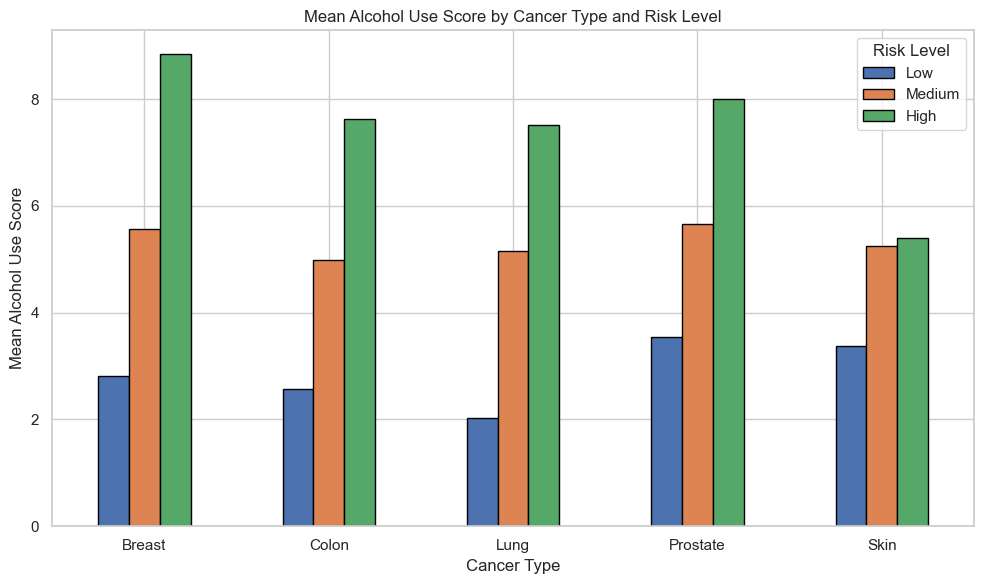

In [19]:
alcohol_combined.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Mean Alcohol Use Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Alcohol Use Score')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [20]:
# Physical Activity score across Cancer Types
physical_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Physical_Activity'].mean().unstack()

physical_combined = physical_combined.reindex(columns=['Low', 'Medium', 'High'])

print(physical_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       3.72    4.10  5.15
Colon        3.36    4.18  4.55
Lung         3.15    4.00  4.98
Prostate     3.65    3.77  4.33
Skin         4.37    3.98  5.60


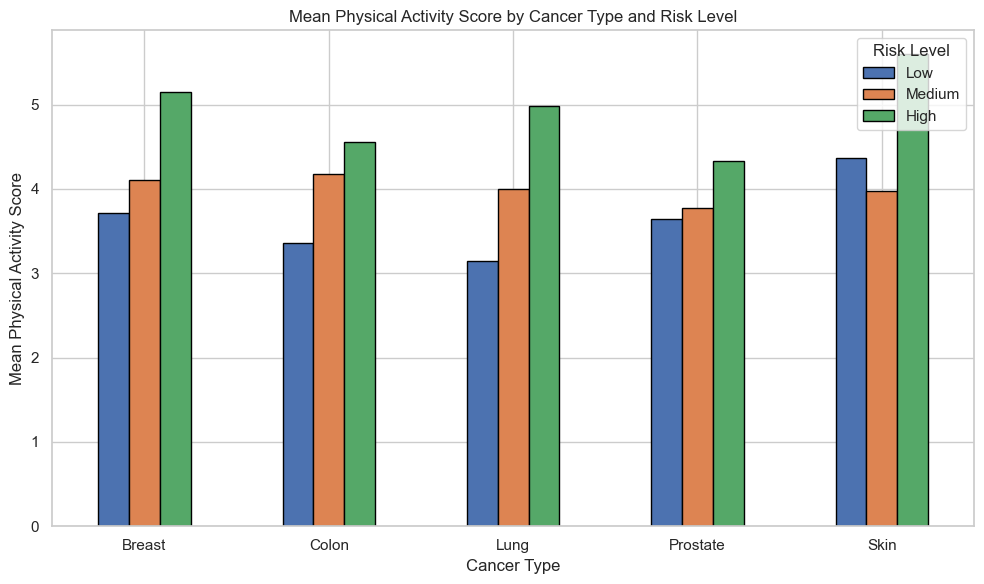

In [21]:
physical_combined.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Mean Physical Activity Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Physical Activity Score')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [22]:
# Obesity score across Cancer Types
obesity_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Obesity'].mean().unstack()

obesity_combined = obesity_combined.reindex(columns=['Low', 'Medium', 'High'])

print(obesity_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       7.87    8.34  9.08
Colon        3.02    5.33  7.55
Lung         2.94    5.36  6.45
Prostate     4.46    5.75  8.33
Skin         3.47    5.60  7.70


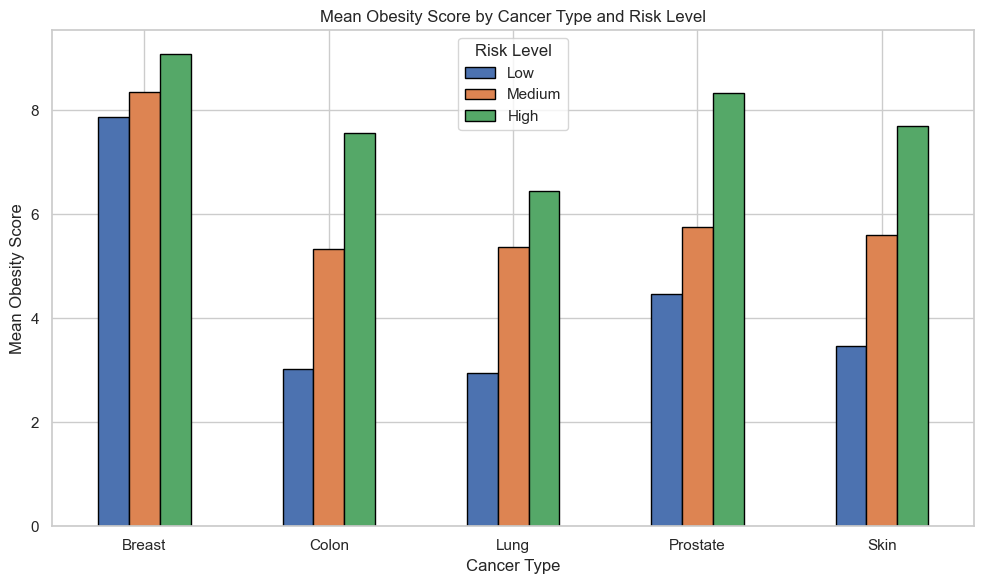

In [23]:
obesity_combined.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Mean Obesity Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Obesity Score')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

### Dietary risk-factor patterns, including red-meat consumption, salt and processed-food consumption, fruit and vegetable intake, and calcium intake associated with cancer types and risk levels

In [24]:
# Red Meat Consumption
red_meat_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Diet_Red_Meat'].mean().unstack()

red_meat_combined = red_meat_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(red_meat_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       3.54    4.56  6.69
Colon        7.54    8.64  8.83
Lung         2.71    4.08  6.66
Prostate     3.15    5.01  7.33
Skin         2.90    4.29  7.30


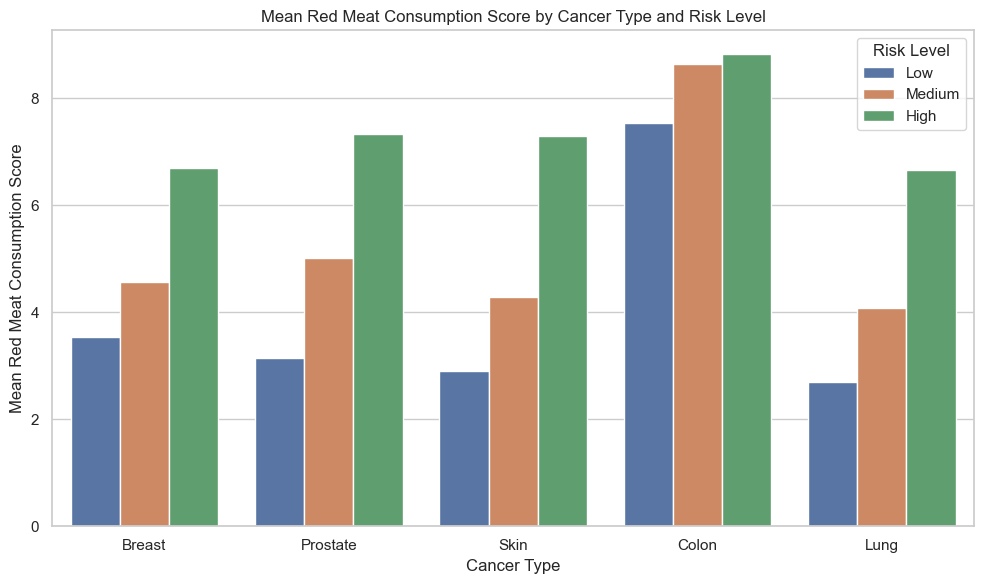

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Diet_Red_Meat',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Red Meat Consumption Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Red Meat Consumption Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [26]:
# Salted and Processed Food
processed_food_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Diet_Salted_Processed'].mean().unstack()

processed_food_combined = processed_food_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(processed_food_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       2.61    4.63  5.62
Colon        4.51    6.01  7.59
Lung         2.03    4.19  6.83
Prostate     2.86    4.29  8.67
Skin         2.10    4.61  7.80


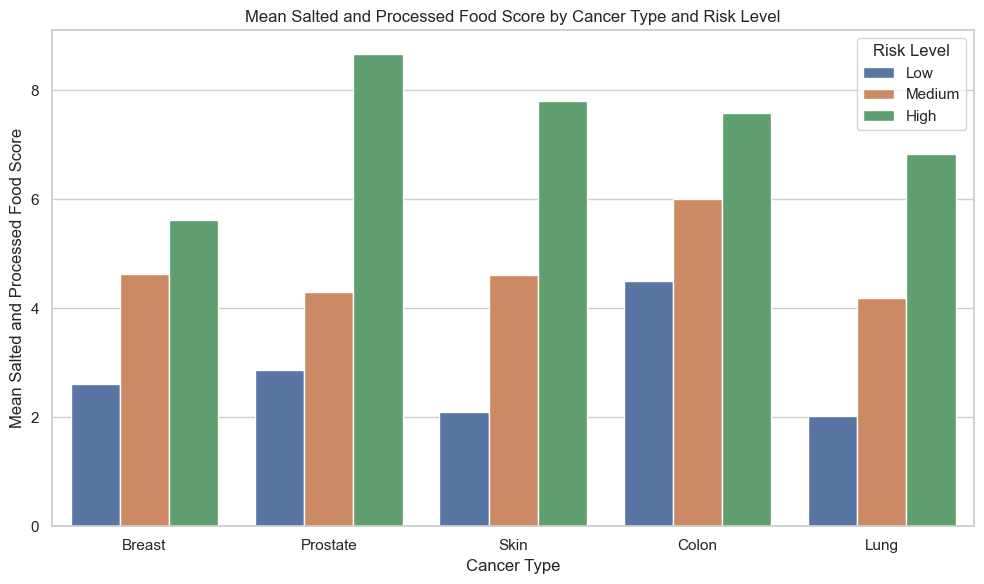

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Diet_Salted_Processed',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Salted and Processed Food Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Salted and Processed Food Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [28]:
# Fruit and Vegetable Intake
fruit_veg_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Fruit_Veg_Intake'].mean().unstack()

fruit_veg_combined = fruit_veg_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(fruit_veg_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       5.78    4.90  4.62
Colon        4.05    3.65  2.48
Lung         5.97    5.67  4.77
Prostate     6.10    4.80  1.33
Skin         6.39    4.89  3.90


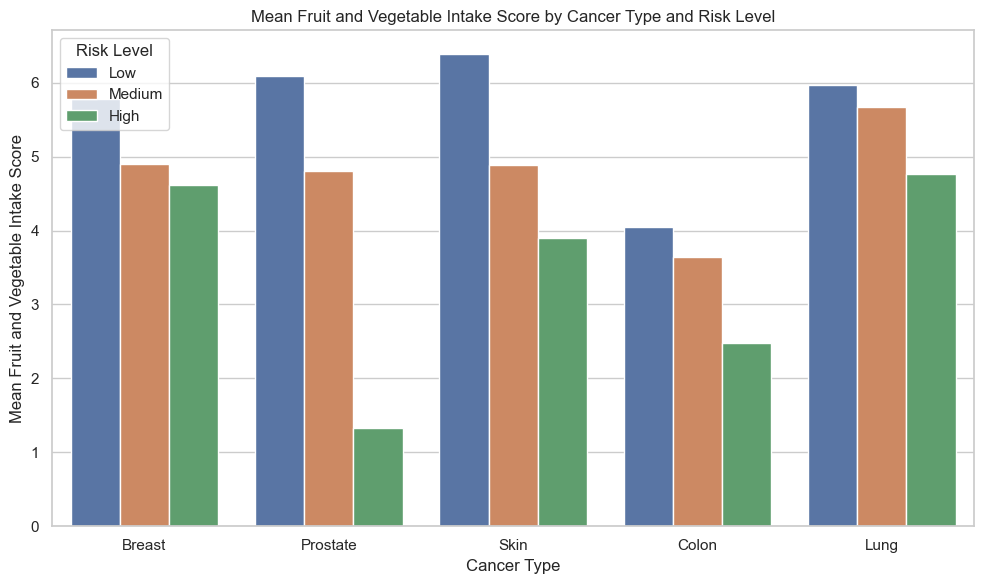

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Fruit_Veg_Intake',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Fruit and Vegetable Intake Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Fruit and Vegetable Intake Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [30]:
# Calcium Intake
calcium_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Calcium_Intake'].mean().unstack()

calcium_combined = calcium_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(calcium_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       1.85    2.17  1.92
Colon        4.42    4.53  4.34
Lung         4.26    4.54  5.02
Prostate     4.02    4.57  2.67
Skin         4.86    4.34  4.60


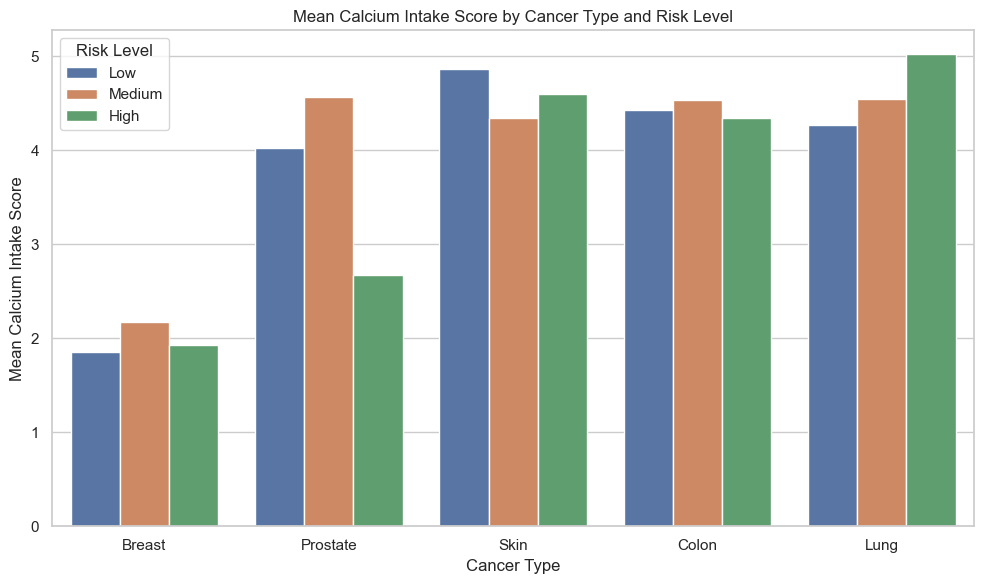

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Calcium_Intake',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Calcium Intake Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Calcium Intake Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

### Genetic and health-related factors, including family history, BRCA mutation, H. pylori infection, and body mass index (BMI), across different cancer types and risk levels. 

In [32]:
# Family History
family_history_combined = (
    cancer_df.assign(
        Family_History_Yes=cancer_df['Family_History'].eq('Yes').astype(int)
    )
    .groupby(['Cancer_Type', 'Risk_Level'])['Family_History_Yes']
    .mean()
    .unstack() * 100
)

family_history_combined = family_history_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(family_history_combined.round(2))

Risk_Level     Low  Medium   High
Cancer_Type                      
Breast       12.36   23.18  23.08
Colon        13.56   20.91  20.69
Lung          5.88   19.73  17.02
Prostate     18.28   21.05  33.33
Skin         14.29   16.88  30.00


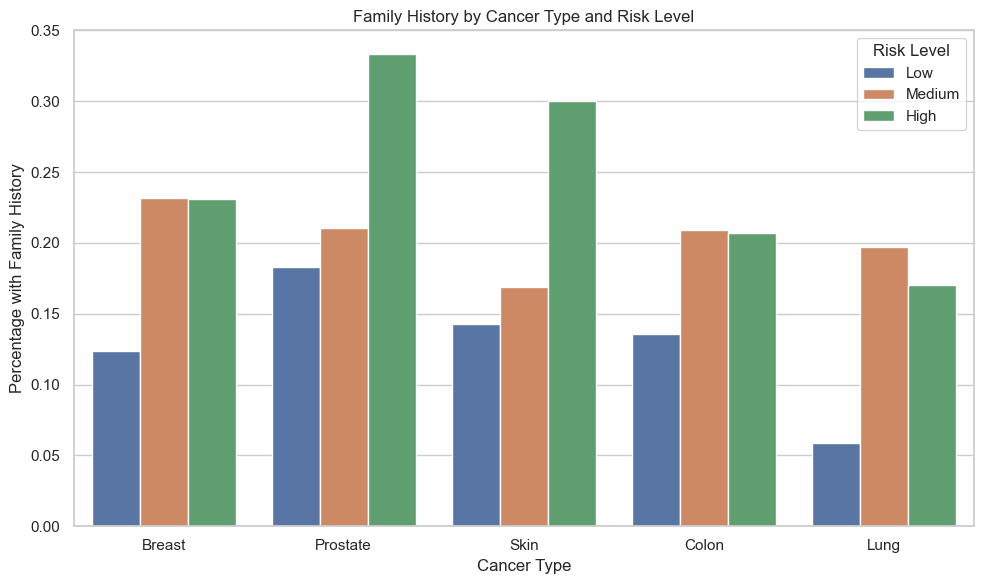

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y=cancer_df['Family_History'].eq('Yes').astype(int),
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Family History by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Percentage with Family History')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [34]:
# BRCA Mutation
brca_combined = (
    cancer_df.assign(
        BRCA_Yes=cancer_df['BRCA_Mutation'].eq('Yes').astype(int)
    )
    .groupby(['Cancer_Type', 'Risk_Level'])['BRCA_Yes']
    .mean()
    .unstack() * 100
)

brca_combined = brca_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(brca_combined.round(2))

Risk_Level    Low  Medium   High
Cancer_Type                     
Breast       8.99    7.54  15.38
Colon        1.69    3.33   6.90
Lung         0.00    1.35   2.13
Prostate     3.23    0.48   0.00
Skin         0.00    1.30   0.00


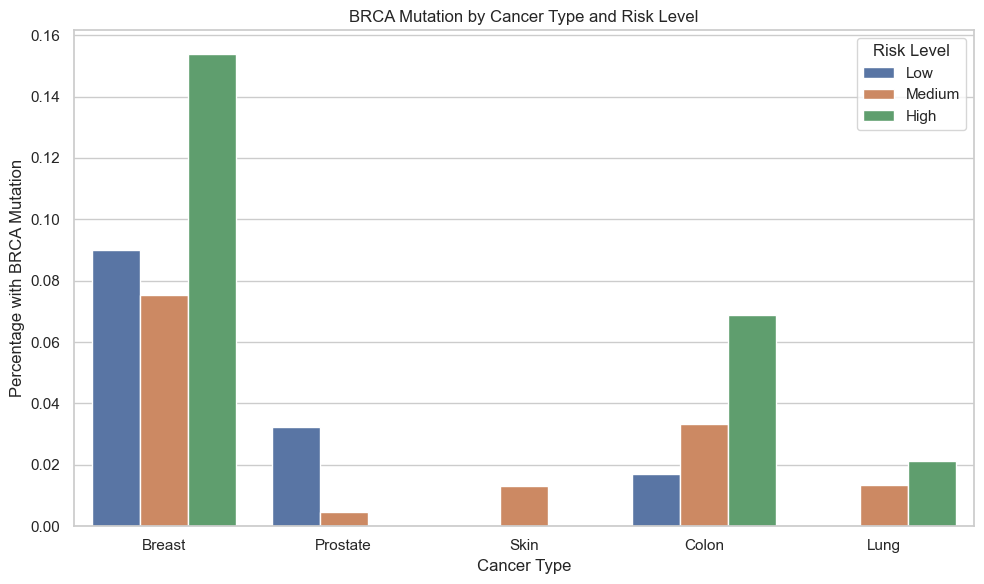

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y=cancer_df['BRCA_Mutation'].eq('Yes').astype(int),
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('BRCA Mutation by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Percentage with BRCA Mutation')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [36]:
# H. Pylori Infection
hpylori_combined = (
    cancer_df.assign(
        HPylori_Yes=cancer_df['H_Pylori_Infection'].eq('Yes').astype(int)
    )
    .groupby(['Cancer_Type', 'Risk_Level'])['HPylori_Yes']
    .mean()
    .unstack() * 100
)

hpylori_combined = hpylori_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(hpylori_combined.round(2))

Risk_Level     Low  Medium   High
Cancer_Type                      
Breast       21.35   23.46  23.08
Colon        15.25   19.09  13.79
Lung         20.59   15.25  34.04
Prostate     12.90   20.10   0.00
Skin         20.41   23.38  20.00


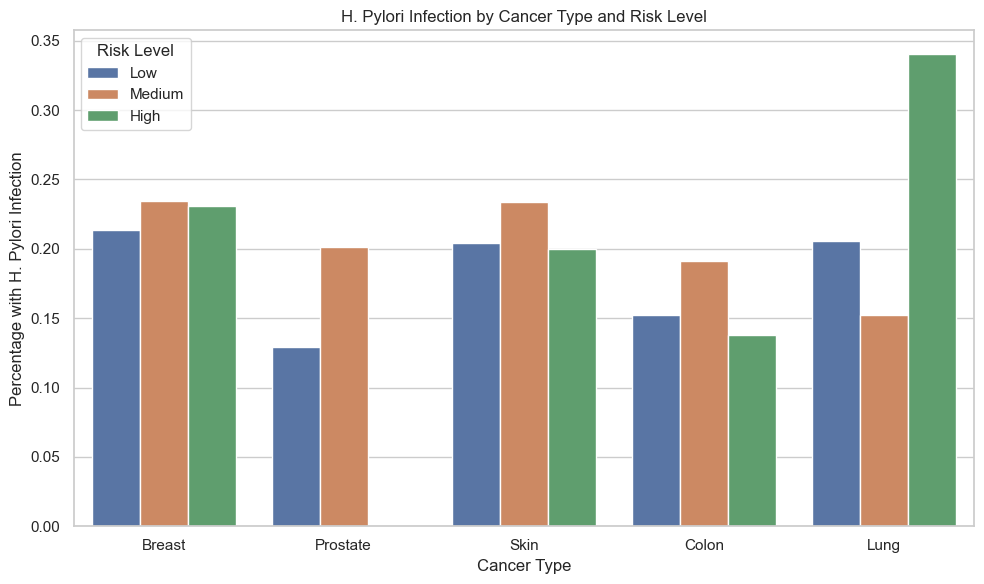

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y=cancer_df['H_Pylori_Infection'].eq('Yes').astype(int),
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('H. Pylori Infection by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Percentage with H. Pylori Infection')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [38]:
# BMI
bmi_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['BMI'].mean().unstack()

bmi_combined = bmi_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(bmi_combined.round(2))

Risk_Level     Low  Medium   High
Cancer_Type                      
Breast       25.72   26.07  26.48
Colon        25.96   26.26  25.71
Lung         25.05   26.22  26.69
Prostate     25.81   26.67  23.90
Skin         26.35   26.24  25.92


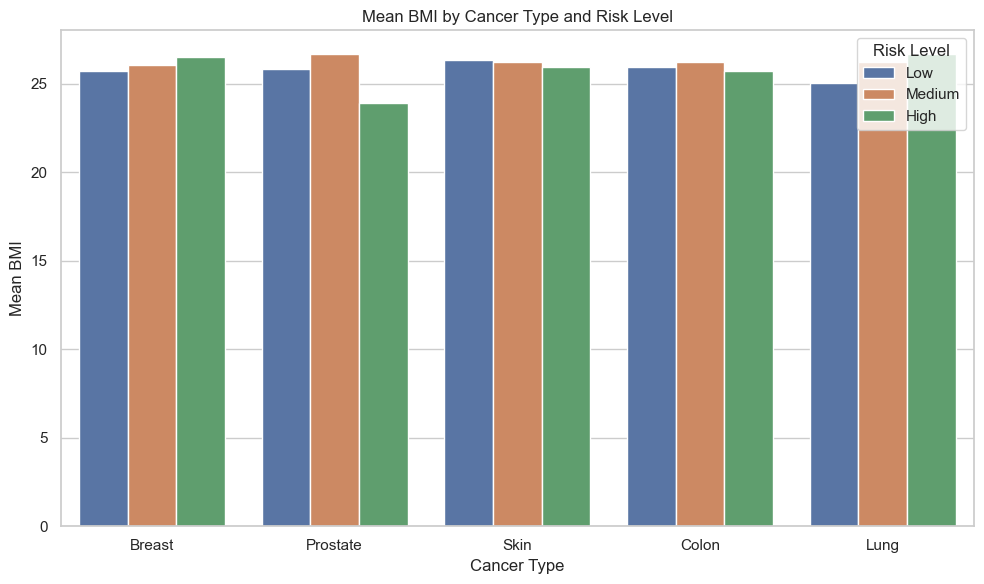

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='BMI',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean BMI by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean BMI')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

### Environmental and occupational exposure patterns, particularly air pollution and occupational hazards, across different cancer types and Risk levels.

In [40]:
# Air Pollution
air_pollution_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Air_Pollution'].mean().unstack()

air_pollution_combined = air_pollution_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(air_pollution_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       2.13    4.65  7.15
Colon        2.10    4.45  8.07
Lung         5.91    7.56  9.30
Prostate     2.45    4.28  7.67
Skin         4.33    6.16  8.40


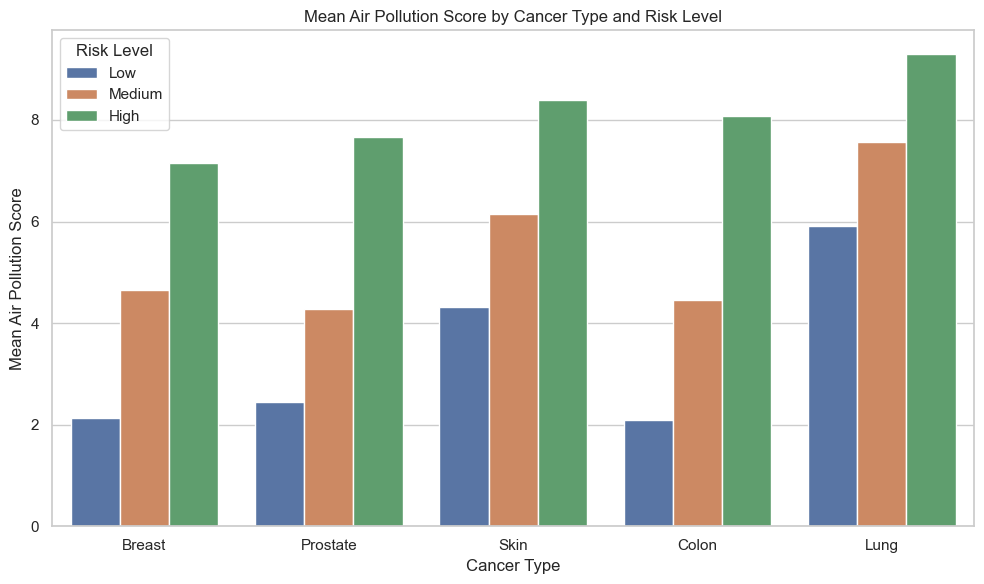

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Air_Pollution',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Air Pollution Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Air Pollution Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [42]:
# Occupational Hazards
occupational_hazards_combined = cancer_df.groupby(
    ['Cancer_Type', 'Risk_Level']
)['Occupational_Hazards'].mean().unstack()

occupational_hazards_combined = occupational_hazards_combined.reindex(
    columns=['Low', 'Medium', 'High']
)

print(occupational_hazards_combined.round(2))

Risk_Level    Low  Medium  High
Cancer_Type                    
Breast       2.78    4.79  6.85
Colon        2.36    4.44  6.90
Lung         2.21    4.37  6.96
Prostate     3.25    5.44  4.67
Skin         6.67    8.19  8.30


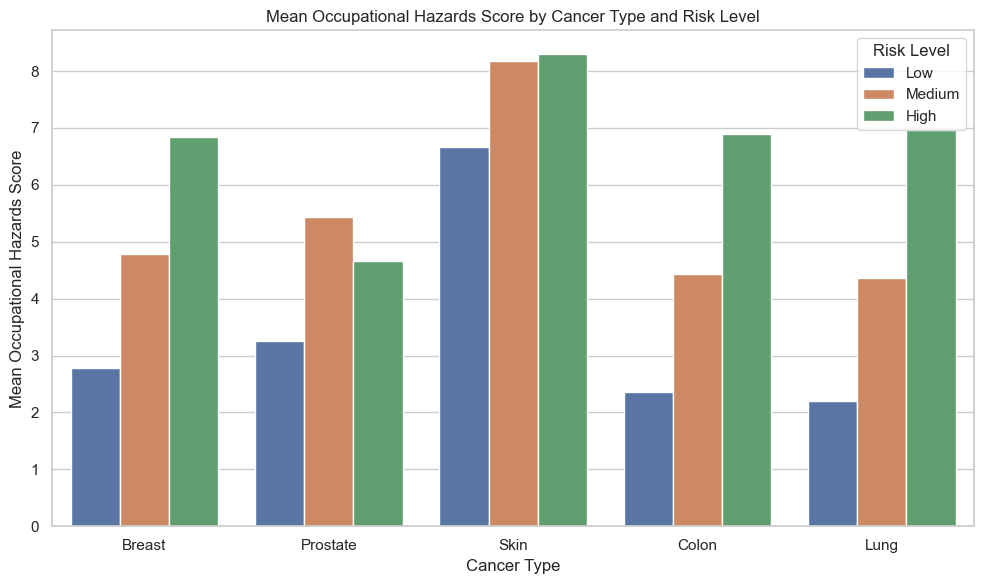

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancer_df,
    x='Cancer_Type',
    y='Occupational_Hazards',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    estimator='mean',
    errorbar=None
)

plt.title('Mean Occupational Hazards Score by Cancer Type and Risk Level')
plt.xlabel('Cancer Type')
plt.ylabel('Mean Occupational Hazards Score')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

### Relationship between numeric variables and cancer risk. 

# FEATURE ENGINEERING

In [44]:
feature_df=cancer_df.copy()
feature_df.head()

,Patient_ID,Cancer_Type,Age,Age_group,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,BMI,BMI category,Overall_Risk_Score,Risk_Level
0,LU0000,Breast,68,Older Adult,Female,7,2,8,No,5,...,4,6,3,Yes,No,0,28.0,Overweight,0.398696,Medium
1,LU0001,Prostate,74,Older Adult,Male,8,9,8,No,0,...,1,3,3,No,No,5,25.4,Overweight,0.424299,Medium
2,LU0002,Skin,55,Middle-Aged,Male,7,10,7,No,3,...,1,8,10,No,No,6,28.6,Overweight,0.605082,Medium
3,LU0003,Colon,61,Middle-Aged,Female,6,2,2,No,6,...,6,4,8,No,No,8,32.1,Obese,0.318449,Low
4,LU0004,Lung,67,Older Adult,Male,10,7,4,No,6,...,9,10,9,No,No,5,25.1,Overweight,0.524358,Medium


In [45]:
## dropping uncessary columns

feature_df = feature_df.drop(columns=['Patient_ID','Age_group','BMI category','Overall_Risk_Score'])
feature_df.head()

,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,BMI,Risk_Level
0,Breast,68,Female,7,2,8,No,5,3,7,4,6,3,Yes,No,0,28.0,Medium
1,Prostate,74,Male,8,9,8,No,0,3,7,1,3,3,No,No,5,25.4,Medium
2,Skin,55,Male,7,10,7,No,3,3,4,1,8,10,No,No,6,28.6,Medium
3,Colon,61,Female,6,2,2,No,6,2,4,6,4,8,No,No,8,32.1,Low
4,Lung,67,Male,10,7,4,No,6,3,10,9,10,9,No,No,5,25.1,Medium


In [46]:
# convert categorical variables to numerical
feature_df['Gender'] = feature_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

feature_df['Family_History'] = feature_df['Family_History'].map({
    'Yes': 1,
    'No': 0
})

feature_df['BRCA_Mutation'] = feature_df['BRCA_Mutation'].map({
    'Yes': 1,
    'No': 0
})

feature_df['H_Pylori_Infection'] = feature_df['H_Pylori_Infection'].map({
    'Yes': 1,
    'No': 0
})

feature_df['Risk_Level'] = feature_df['Risk_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

feature_df = pd.get_dummies(
    feature_df,
    columns=['Cancer_Type'],
    dtype=int
)

feature_df.head()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,BMI,Risk_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,68,0,7,2,8,0,5,3,7,4,...,1,0,0,28.0,1,1,0,0,0,0
1,74,1,8,9,8,0,0,3,7,1,...,0,0,5,25.4,1,0,0,0,1,0
2,55,1,7,10,7,0,3,3,4,1,...,0,0,6,28.6,1,0,0,0,0,1
3,61,0,6,2,2,0,6,2,4,6,...,0,0,8,32.1,0,0,1,0,0,0
4,67,1,10,7,4,0,6,3,10,9,...,0,0,5,25.1,1,0,0,1,0,0


### MODEL CREATION

In [47]:
# Split the dataset into features and target variable
X = feature_df.drop(columns='Risk_Level')
y = feature_df['Risk_Level']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [50]:
# Define the models
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Define a dictionary to hold the models
models = {
    'KNN': knn_model,
    'SVM': svm_model,
    'Random Forest': rf_model
}

In [51]:
results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_weighted',
            'recall': 'recall_weighted',
            'f1': 'f1_weighted'
        }
    )

    results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1 Score': scores['test_f1'].mean()
    }

results_df = pd.DataFrame(results).T

print(results_df.round(4))

c:\Users\DELL\anaconda3\envs\tf-env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               Accuracy  Precision  Recall  F1 Score
KNN              0.8169     0.8016  0.8169    0.7936
SVM              0.8569     0.8581  0.8569    0.8350
Random Forest    0.8325     0.8199  0.8325    0.7925


c:\Users\DELL\anaconda3\envs\tf-env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [52]:
best_model_name = results_df['Accuracy'].idxmax()

print("Best model:", best_model_name)
best_model = models[best_model_name]

Best model: SVM


In [53]:
# Train the best model on the entire training set and evaluate on the test set
svm_model.fit(X_train, y_train)
y_train_pred = svm_model.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       259
           1       0.91      0.98      0.95      1259
           2       1.00      0.33      0.50        82

    accuracy                           0.91      1600
   macro avg       0.94      0.69      0.76      1600
weighted avg       0.92      0.91      0.91      1600



In [54]:
y_test_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.66      0.74        65
           1       0.89      0.97      0.93       315
           2       1.00      0.15      0.26        20

    accuracy                           0.88       400
   macro avg       0.90      0.59      0.64       400
weighted avg       0.88      0.88      0.86       400



### Saving Model

In [55]:
import joblib

joblib.dump(svm_model, "cancer_risk_model.pkl")

['cancer_risk_model.pkl']